In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py

import tensorflow as tf
tf.config.experimental.set_memory_growth(tf.config.list_physical_devices(device_type="GPU")[0], True)
# tf.config.run_functions_eagerly(True)

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from tqdm import tqdm
from icecream import ic

from msfm.grid_pipeline import GridPipeline
from msfm.utils import logger, input_output, files, scales, power_spectra, parameters

from deep_lss.models.grid_model import GridLossModel
from deep_lss.utils import optimization
from deep_lss.nets.mlp import MultiLayerPerceptron

from msi.utils import preprocessing, dataset

In [3]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v9/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/v11desy3/v9/linear_bias"
# out_dir = "/pscratch/sd/a/athomsen/run_files/v9"

conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v10/linear_bias.yaml")
base_dir = "/pscratch/sd/a/athomsen/v11desy3/v10/linear_bias"
out_dir = "/pscratch/sd/a/athomsen/run_files/v10"

# with_lensing = True
# with_clustering = False
# params = ["Om", "s8", "w0", "Aia", "n_Aia"]

with_lensing = False
with_clustering = True
params = ["Om", "s8", "w0", "bg", "n_bg"]

In [4]:
batch_size = 2**12
# batch_size = 2**8
shuffle_buffer = 4*batch_size

l_mins = 8 * [30]
def angle_to_ell(angles):
    return list(scales.angle_to_ell(np.array(angles), arcmin=True))
l_maxs = angle_to_ell([22.1, 15.1, 11.2, 9.4] + [65.1, 44.5, 34.1, 28.5])
n_bins = 33

apply_log = True
standardize = True
pca_components = None

cl_dset_train, cl_dset_test, out_dict, scaler, pca = dataset.get_binned_power_spectra_dset(
    base_dir, 
    # configuration
    conf=conf, 
    params=params,
    # selection
    with_lensing=with_lensing,
    with_clustering=with_clustering,
    # dset
    batch_size=batch_size,
    shuffle_buffer=shuffle_buffer,
    # power spectra
    l_mins=l_mins,
    l_maxs=l_maxs,
    n_bins=n_bins,
    # additional preprocessing
    apply_log=apply_log,
    standardize=standardize,
    pca_components=pca_components,

)

24-08-29 06:07:55 preprocessin INF   Applying scale cuts to the raw Cls 
24-08-29 06:07:55 preprocessin INF   l_mins = [30, 30, 30, 30, 30, 30, 30, 30] 
24-08-29 06:07:55 preprocessin INF   l_maxs = [488.6877828054298, 715.2317880794702, 964.2857142857142, 1148.936170212766, 165.89861751152074, 242.69662921348313, 316.7155425219941, 378.94736842105266] 
24-08-29 06:08:07 input_output INF   Array shapes: 
24-08-29 06:08:07 input_output INF   fiducial/i_example = (39920,) 
24-08-29 06:08:07 input_output INF   fiducial/i_noise   = (39920,) 
24-08-29 06:08:08 input_output INF   fiducial/cls/binned = (39920, 64, 36) 
24-08-29 06:08:08 input_output INF   fiducial/cls/bin_edges = (65, 36) 
24-08-29 06:08:08 input_output INF   grid/cosmo         = (2500, 400, 12) 
24-08-29 06:08:08 input_output INF   grid/i_example     = (2500, 400) 
24-08-29 06:08:08 input_output INF   grid/i_noise       = (2500, 400) 
24-08-29 06:08:08 input_output INF   grid/i_sobol       = (2500, 400) 
24-08-29 06:08:22 in

In [5]:
n_cls = out_dict["grid/cls/train"].shape[-1]
n_params = len(params)
# n_summary = 2 * n_params
n_summary = n_params
num_hidden_units = 256
num_layers = 4
dropout_rate = 0.1

def get_cl_summary_network(n_summary=n_summary):
    mlp = MultiLayerPerceptron(
        output_size=n_summary, 
        num_hidden_units=num_hidden_units, 
        num_layers=num_layers, 
        dropout_rate=dropout_rate
    )
    mlp.build((None, n_cls))
    
    return mlp

In [6]:
def train_model(model, n_steps=10_000, do_validation=True):  
    train_losses = []
    train_steps = []
    vali_steps = []
    vali_losses = []
    for i, (cl_batch, cosmo_batch) in tqdm(enumerate(cl_dset_train.take(n_steps+1)), total=n_steps):
        train_losses.append(model.grid_train_step(cl_batch, cosmo_batch))
        train_steps.append(i)
        
        if i % 1_000 == 0 and i !=0 and do_validation:
            vali_loss = []
            for cl_batch, cosmo_batch in cl_dset_test:
                vali_loss.append(model.vali_loss_fn(model(cl_batch, training=False), cosmo_batch))
            vali_losses.append(np.mean(vali_loss))
            vali_steps.append(i)

    fig, ax = plt.subplots()
    # ax.plot(train_steps[100:], train_losses[100:], label="training")
    ax.plot(train_steps, train_losses, label="training")
    if do_validation:
        ax.plot(vali_steps, vali_losses, label="validation")
        print(f"final validation loss = {vali_losses[-1]}")
    ax.legend()


# variational lower bound

24-08-29 06:11:26 base_model.p INF   Initializing with a normal Sequential model 
24-08-29 06:11:26 base_model.p INF   The network is initialized from scratch. 
24-08-29 06:11:26 grid_model.p INF   Initialized the GridLossModel 
24-08-29 06:11:26 grid_model.p WAR   Mutual info loss, overwriting the checkpoint manager 
24-08-29 06:11:26 grid_model.p WAR   Using the mutual information loss with the variational estimator 
24-08-29 06:11:26 grid_model.p INF   Set up the training step of the mutual_info loss 


  0%|          | 0/1000 [00:00<?, ?it/s]

24-08-29 06:11:27 grid_model.p WAR   Tracing grid_train_step 
24-08-29 06:11:27 base_model.p WAR   Performing a base_train_step in python instead of a tf.function 
24-08-29 06:11:27 grid_model.p WAR   Tracing grid_train_step 
24-08-29 06:11:27 base_model.p WAR   Performing a base_train_step in python instead of a tf.function 


1001it [00:06, 163.36it/s]                         

24-08-29 06:11:33 base_model.p INF   Successfully saved the model in grid_checkpoint 


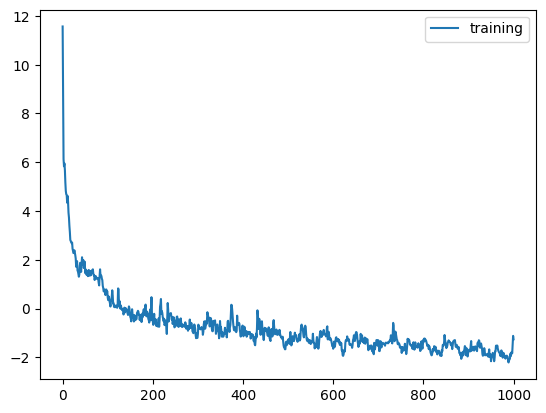

In [10]:
n_steps = 1_000

summary_net = get_cl_summary_network()

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

model = GridLossModel(
    summary_net,
    n_side=None,
    indices=None,
    optimizer=optimizer,
    checkpoint_dir="grid_checkpoint",
)

model.setup_grid_loss_step(
    batch_size=batch_size,
    dim_theta=n_params,
    loss="mutual_info",
    dim_x=n_cls,
    dim_summary=n_summary,
    mutual_info_estimator="variational",
    clip_by_global_norm=1.0,
    mutual_info_kwargs={"full_covariance": False}
)

train_model(model, n_steps, do_validation=False)
model.save_model()

In [14]:
print(model(out_dict["fidu/cls"])[0].numpy())

[-1.1562915  -0.5330587  -0.42354807  0.6480265  -0.15896726]


# load the model

In [15]:
n_steps = 1_000

summary_net = get_cl_summary_network()

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

model = GridLossModel(
    summary_net,
    n_side=None,
    indices=None,
    optimizer=optimizer,
    checkpoint_dir="grid_checkpoint",
    restore_checkpoint=True
)

print(model(out_dict["fidu/cls"])[0].numpy())

model.setup_grid_loss_step(
    batch_size=batch_size,
    dim_theta=n_params,
    loss="mutual_info",
    dim_x=n_cls,
    dim_summary=n_summary,
    mutual_info_estimator="variational",
    clip_by_global_norm=1.0,
    mutual_info_kwargs={"full_covariance": False}
)

print(model(out_dict["fidu/cls"])[0].numpy())

24-08-29 06:12:28 base_model.p INF   Initializing with a normal Sequential model 
24-08-29 06:12:28 base_model.p INF   Network successfully restored from checkpoint grid_checkpoint/ckpt-1. 
24-08-29 06:12:28 grid_model.p INF   Initialized the GridLossModel 
[-1.1562915  -0.5330587  -0.42354807  0.6480265  -0.15896726]
24-08-29 06:12:28 grid_model.p WAR   Mutual info loss, overwriting the checkpoint manager 
24-08-29 06:12:28 grid_model.p WAR   Mutual info loss, restoring the model again from within setup_grid_loss_step 
24-08-29 06:12:28 base_model.p INF   Network successfully restored from checkpoint grid_checkpoint/ckpt-1. 
24-08-29 06:12:28 grid_model.p WAR   Using the mutual information loss with the variational estimator 
24-08-29 06:12:28 grid_model.p INF   Set up the training step of the mutual_info loss 
[-1.1562915  -0.5330587  -0.42354807  0.6480265  -0.15896726]


  0%|          | 0/1000 [00:00<?, ?it/s]

24-08-29 06:12:38 grid_model.p WAR   Tracing grid_train_step 
24-08-29 06:12:38 base_model.p WAR   Performing a base_train_step in python instead of a tf.function 
24-08-29 06:12:39 grid_model.p WAR   Tracing grid_train_step 
24-08-29 06:12:39 base_model.p WAR   Performing a base_train_step in python instead of a tf.function 


1001it [00:06, 163.71it/s]                         


[-0.5257917  -0.13039501 -0.03182122  0.12037158 -0.07699306]


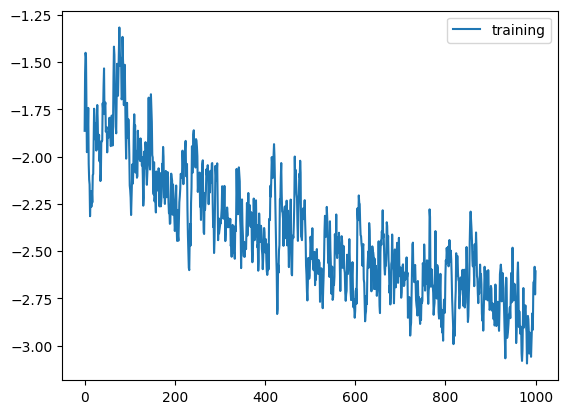

In [16]:
train_model(model, n_steps, do_validation=False)
print(model(out_dict["fidu/cls"])[0].numpy())